In [1]:
%matplotlib widget

In [2]:
from astropy.io import fits
import matplotlib.pyplot as plt
import numpy as np
from scipy.optimize import curve_fit
from astropy.modeling import models
from scipy.signal import convolve
from scipy.optimize import minimize
from astropy.convolution import Gaussian1DKernel
import scipy.integrate as integrate
from scipy.optimize import differential_evolution
import pandas as pd
import os

In [3]:
spectra_c = []
spectra_dx = []
spectra_sx = []

for i in range(1, 3):
    df = pd.read_csv(f"Spectrum_center_{i}_gas_exp.csv")
    spectra_c.append(df)

for i in range(1, 3):
    df = pd.read_csv(f"Spectrum_dx_{i}_gas_exp.csv")
    spectra_dx.append(df)

for i in range(1, 3):
    df = pd.read_csv(f"Spectrum_sx_{i}_gas_exp.csv")
    spectra_sx.append(df)

In [4]:
def Ku03(x):
    # AGN selection based on Kauffman et al. 2003
    # log OIII/Hb > 0.61/(log NII/Ha - 0.05) + 1.3
    return 0.61/(x - 0.05) + 1.3

def Ke01(x):
     # AGN selection based on Kewley et al. 2001
     # log OIII/Hb > 0.61/(log NII/Ha - 0.47) + 1.19
     return 0.61/(x - 0.47) + 1.19

def S06(x):
    # AGN selection based on Stasinska et al 2006
     # log OIII/Hb > 0.29/(log NII/Ha +0.20) + 0.96
    return 0.29/(x + 0.20) + 0.96

def C10(x):
 # Seyfert–LINER line based on Cid Fernandes et al 2010
    return 1.01*x + 0.48

def Ke01_SII(x):
     # AGN selection based on Kewley et al. 2001
     # log OIII/Hb > 0.72/(log SII/Ha - 0.32) + 1.3
     return 0.72/(x - 0.32) + 1.3

def Ke06(x):
    #Seyfert–LINER line
    return 1.89* x + 0.76

def real_flux(spectrum_sx, spectrum_c, spectrum_dx):
    flux_sx = spectrum_sx['Flux']
    flux_c = spectrum_c['Flux']
    flux_dx = spectrum_dx['Flux']
    err_flux_sx = spectrum_sx['Error_flux']
    err_flux_c = spectrum_c['Error_flux']
    err_flux_dx = spectrum_dx['Error_flux']
    num = [1, 2, 3, 8, 12]
    real_err = []
    real_flux = []
    for i in num:
        mean = np.mean([flux_sx[i], flux_dx[i]])
        real_flux.append(flux_c[i] - mean)

        real_err.append(np.sqrt(err_flux_c[i]**2 + (err_flux_sx[i]/2)**2 + (err_flux_dx[i]/2)**2))
    
    print(real_flux, real_err)
        
    return np.array(real_flux), np.array(real_err)

def one_diff_flux(spectrum_l, spectrum_c):
    flux_l = spectrum_l['Flux']
    flux_c = spectrum_c['Flux']
    err_flux_l = spectrum_l['Error_flux']
    err_flux_c = spectrum_c['Error_flux']
    
    num = [1, 2, 3, 8, 12]
    real_err = []
    real_flux = []
    for i in num:
        real_flux.append(flux_c[i] - flux_l[i])

        real_err.append(np.sqrt(err_flux_c[i]**2 + (err_flux_l[i])**2))
    
    print(real_flux, real_err)
        
    return np.array(real_flux), np.array(real_err)
    
def error_ratio(err_1, err_2, flux_1, flux_2):
    try:
        e_1 = err_1 / (flux_1 * np.log(10)) if flux_1 != 0 else np.nan
        e_2 = err_2 / (flux_2 * np.log(10)) if flux_2 != 0 else np.nan
        return np.sqrt(e_1**2 + e_2**2)
    except:
        return np.nan

def ratio(flux, err_flux):

    HB   = flux[0]
    HA   = flux[1]
    SII  = flux[2]
    OIII = flux[3]
    NII  = flux[4]
   
    OIII_HB = np.log10(OIII / HB) #if OIII > 0 and HB > 0 #else np.nan
    NII_HA  = np.log10(NII / HA) # if NII >  0 and HA > 0 #else np.nan
    SII_HA  = np.log10(SII / HA) # if SII > 0 and HA > 0 #else np.nan
    print('log ratio OIII_HB: ', OIII_HB)
    print('log ratio NII_HA: ', NII_HA)
    print('log ratio SII_HA: ', SII_HA)

    err_OIII_HB = error_ratio(err_flux[3], err_flux[0], OIII, HB)
    err_NII_HA  = error_ratio(err_flux[4], err_flux[1], NII, HA)
    err_SII_HA  = error_ratio(err_flux[2], err_flux[1], SII, HA)

    return OIII_HB, NII_HA, SII_HA, err_OIII_HB, err_NII_HA, err_SII_HA

[5.9401251615842705, 29.73497176505319, 0.9335469490135639, 9.367327495381085, 5.603336978573769] [1.1507114610001787, 1.5460031014086222, 0.769855461479436, 1.0846974681657826, 0.4310199262299579]
log ratio OIII_HB:  0.19782010816922724
log ratio NII_HA:  -0.7248207892002755
log ratio SII_HA:  -1.5031313665096937
[2.2806837345674285, 12.321151293118234, 0.7715724758657793, 1.508050054725889, 5.24200260805492] [0.22649944263351887, 0.15971036431728464, 0.33439456413712443, 0.19088942448208795, 0.10343185070280385]
log ratio OIII_HB:  -0.17964930852159552
log ratio NII_HA:  -0.37115405768269194
log ratio SII_HA:  -1.2032745636107685
[0.20480614083766402, 0.9548280046017772, 0.0736171066203315, 0.1718494548143375, 0.28535839173890265] [0.10174964279182823, 0.10866339220087658, 0.1208804983582791, 0.05226896725761931, 0.058262643205765]
log ratio OIII_HB:  -0.07619481554384001
log ratio NII_HA:  -0.5245344994675072
log ratio SII_HA:  -1.1129464038180659
[3.3521475988623006, 15.15644705819

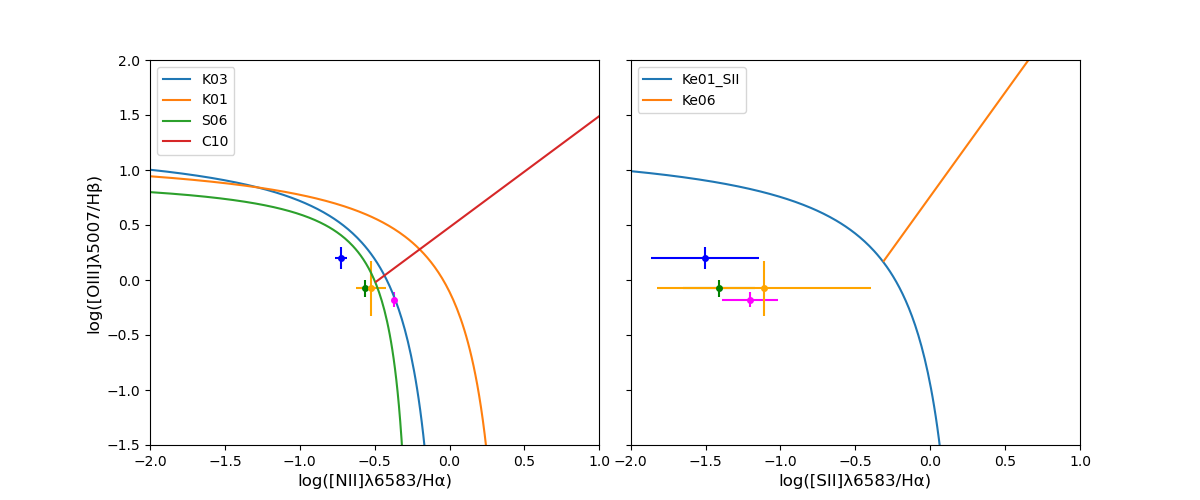

In [7]:
NII_HA = np.zeros(len(spectra_c))
OIII_HB = np.zeros(len(spectra_c))
SII_HA = np.zeros(len(spectra_c))
err_OIII_HB = np.zeros(len(spectra_c))
err_NII_HA = np.zeros(len(spectra_c))
err_SII_HA = np.zeros(len(spectra_c))

fig, ax = plt.subplots(1, 2, figsize=(12, 5), sharey = True)
colors = ['blue', 'green', 'magenta', 'orange']
num_both = [0, 2]
num_single = [1, 3]
for i in num_both:
    diff_flux, diff_err = real_flux(spectra_sx[i], spectra_c[i], spectra_dx[i])
    OIII_HB[i], NII_HA[i], SII_HA[i], err_OIII_HB[i], err_NII_HA[i], err_SII_HA[i] = ratio(diff_flux, diff_err)
    #ax[0].errorbar(x = np.log10(NII_HA[i]), y = np.log10(OIII_HB[i]), xerr = err_NII_HA[i], yerr = err_OIII_HB[i], color = colors[i], 
    #markersize = 4, marker = 'o')
    #ax[1].errorbar(x = np.log10(SII_HA[i]), y = np.log10(OIII_HB[i]), xerr = err_SII_HA[i], yerr = err_OIII_HB[i], color = colors[i], 
    #markersize = 4, marker = 'o')

diff_flux, diff_err = one_diff_flux(spectra_sx[3], spectra_c[3])
OIII_HB[3], NII_HA[3], SII_HA[3], err_OIII_HB[3], err_NII_HA[3], err_SII_HA[3] = ratio(diff_flux, diff_err)

diff_flux, diff_err = one_diff_flux(spectra_dx[1], spectra_c[1])
OIII_HB[1], NII_HA[1], SII_HA[1], err_OIII_HB[1], err_NII_HA[1], err_SII_HA[1] = ratio(diff_flux, diff_err)
for i in range(4):
    ax[0].errorbar(x = NII_HA[i], y = OIII_HB[i], xerr = err_NII_HA[i], yerr = err_OIII_HB[i], color = colors[i], 
               markersize = 4, marker = 'o')
    ax[1].errorbar(x = SII_HA[i], y = OIII_HB[i], xerr = err_SII_HA[i], yerr = err_OIII_HB[i], color = colors[i], 
              markersize = 4, marker = 'o')

x = np.linspace(-2, 0.04, num=200)
x1 = np.linspace(-2, 0.457, num=200)
x2 = np.linspace(-2, -0.25, num=200)
x3 = np.linspace(-0.49, 5, num=200)
ax[0].plot(x, Ku03(x), label = 'K03')
ax[0].plot(x1, Ke01(x1), label = 'K01')
ax[0].plot(x2, S06(x2), label = 'S06')

ax[0].plot(x3, C10(x3), label = 'C10')    
ax[0].set_xlim(-2, 1)
ax[0].set_ylim(-1.5, 2)
ax[0].set_xlabel('log([NII]λ6583/Hα)', fontsize=12)
ax[0].set_ylabel('log([OIII]λ5007/Hβ)', fontsize=12)
ax[0].legend()

x = np.linspace(-2, 0.1, num=200)
x1 = np.linspace(-0.31, 1, num=200)
ax[1].plot(x, Ke01_SII(x), label = 'Ke01_SII')
ax[1].plot(x1, Ke06(x1), label = 'Ke06')

ax[1].set_xlim(-2, 1)
ax[1].set_ylim(-1.5, 2)
ax[1].set_xlabel('log([SII]λ6583/Hα)', fontsize=12)
ax[1].legend()

plt.subplots_adjust(wspace=0.07)
plt.savefig('BPT_diff.png', bbox_inches='tight')  

In [8]:
OIII_HB

array([ 0.19782011, -0.07584777, -0.17964931, -0.07619482])

In [9]:
NII_HA

array([-0.72482079, -0.56629954, -0.37115406, -0.5245345 ])

In [10]:
SII_HA

array([-1.50313137, -1.40757953, -1.20327456, -1.1129464 ])

In [11]:
Real_flux

NameError: name 'Real_flux' is not defined